## Fixed point evolution with the different parameters of interst 
This code creates figures on how fixed points change and parameter spaces for which multi-stable regions manifest. In this version, the heterogeneity of non-simulated nodes are sampled from a Normal distirbution whose mean is the heterogeneity of the stimulated node, while the variance of the distribution is changed. 

In [1]:
import os
import sys
import glob
import json
import pickle
import datetime
import itertools
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import networkx as nx
import scipy as sp

import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

sys.path.insert(1, '../utils')
from sklearn.feature_selection import mutual_info_regression as MI

from utils import * 
from plotUtils import *
from fcMeasure import *

%matplotlib inline
plt.rcParams.update({'font.size': 14})

In [2]:
COLOR_MAP = {
                'mediumblue': "Unstable Focus",
                'darkgreen': "Stable Node",
                'red': "Unstable Saddle Point",
                'saddlebrown': "Stable Spiral",
                'purple': "Unstable Spiral",
                'black': "Circle"
            }

In [3]:
def sort_filesK(files):
    # sorting based on K value

    Karr = []
    _results = []

    for _file in files:
        basename = os.path.basename(_file).split('.pkl')[0]
        K = float(basename.split('_')[1])
        Karr.append(K)
        _results.append(_file)

    Karr = np.array(Karr)
    Ksort = np.argsort(Karr)

    _results = np.array(_results)  
    _results = _results[Ksort]
    return _results, Karr[Ksort]

In [4]:
# read parameters from a json file
with open('../params.json', 'r+') as f:
    params = json.load(f)

nTrials = 10
nRealizations = 10

params["N"] = nNodes = 10
minval = -5 / params['gamma']
maxval = 5 / params['gamma']

# time vector
T = params['T'] = 10000
time_ = np.arange(0, T)

t_start = 1000
t_end = T

figureroot = "./results/fp/ConfigureB"
os.makedirs(figureroot, exist_ok=True)

In [5]:
sigeArr = np.array([2.5, 7.5, 10.5, 13.5]); sigSteps = len(sigeArr)
sigiArr = np.array([4.4, 10.5, 13.5, 16.5]); sigSteps = len(sigiArr)

sigVar = np.array([0.1, 2])
Kmin = -1; Kmax = 1; Ksteps = 10
Karr = Kmin + np.arange(0, Ksteps + 1) / Ksteps * (Kmax - Kmin)

In [6]:
rootA = "Setup_A3v"
fp_dir = "results/fixedpoints"

save_str = datetime.datetime(2024, 4, 5)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadA = os.path.join("../", rootA, fp_dir, sub_dir)

In [7]:
%%capture

for Var in sigVar:
    for sige in sigeArr:
        for sigi in sigiArr:
            filepaths = glob.glob(os.path.join(loadA, f"*_sige_{sige:.3f}_sigi_{sigi:.3f}_sigVar_{Var:.2f}.pkl"))
            print(f"E {sige:.3f} - I {sigi:.3f} - No. of files = {len(filepaths)}")
            sortpaths, Karr = sort_filesK(filepaths)

            for nf, filePath in enumerate(sortpaths):
                BaseName = os.path.basename(filePath).split('.pkl')[0]
                K = Karr[nf]
                
                with open(filePath, 'rb') as file_:
                    DataDict = pickle.load(file_)
                
                plot_dict = {'fig_size': (10, 8), 'xlabel': r"$I^1_e$", 'var_name': 'external stimulus'}
                file_str_k = f"Kglob_{K:.3f}_sige_{sige:.3f}_sigi_{sigi:.3f}H_sigVAr_{Var:.2f}.jpg"

                I = np.array(DataDict['FPVar']) / params['gamma']

                DF = dimreduction(DataDict, xVar='I', **params)

                textDelt = max(DF['U']/ params['gamma']) * 0.5
                plt.figure(figsize=(5, 2))
                plt.scatter(I, DF['U'] / params['gamma'], c=DF['FPType'], marker='.')
                plt.ylabel(r'$\psi(\mathbf{u})$', fontsize=16, labelpad=10)
                plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16)
                plt.xlim(0, max(I))
                plt.savefig(os.path.join(figureroot, file_str_k), dpi=300, bbox_inches='tight')
                plt.show()

In [8]:
for Var in sigVar:
    fileName = f'MultiStable_DeltaIH_sigVar_{Var:.2f}.pkl'
    deltaI_arr = np.zeros((len(Karr), len(sigeArr), len(sigiArr)))   # region width in terms of K
    if os.path.isfile(os.path.join(figureroot, fileName)):
        print("File FOUND!")
        with open(os.path.join(figureroot, fileName), 'rb') as f:
            deltaI_arr = pickle.load(f)

    else:
        for nK in range (len(Karr)):
            K = Karr[nK]
            for nSE, sigE in enumerate(sigeArr):
                for nSI, sigI in enumerate(sigiArr):
                    _path = os.path.join(loadA, f"KGlob_{K:.2f}_sige_{sigE:.3f}_sigi_{sigI:.3f}_sigVar_{Var:.2f}.pkl")
                
                    with open(_path, 'rb') as file_:
                        DataDict = pickle.load(file_)

                    I = np.array(DataDict['FPVar']) / params['gamma']
                    IUniq = np.unique(I)
                    IDF = pd.DataFrame(I)
                    FPCount_dict = IDF.value_counts().sort_index().to_dict()

                    FP_count = np.array(list(FPCount_dict.values()))

                    MultiR_id = np.where(FP_count > 1)[0]
                    if len(MultiR_id) == 0:
                        continue

                    Mult_diffid = np.diff(MultiR_id)
                    markers = np.where(Mult_diffid > 5)[0] + 1
                    nRegions = len(markers)

                    if nRegions:
                        segment_delt = []
                        start_marker = 0

                        for i in range(nRegions + 1):
                            if i !=  nRegions:
                                marker = markers[i]
                                segment = MultiR_id[start_marker:marker]
                            else:
                                segment = MultiR_id[start_marker:]
                            
                            if i < nRegions:
                                start_marker = marker

                            segment_delt.append(IUniq[segment[-1]] - IUniq[segment[0]]) if len(segment) > 0 else 0
                        
                        deltaI_arr[nK, nSE, nSI] = sum(segment_delt)

                    else:
                        deltaI_arr[nK, nSE, nSI] = IUniq[MultiR_id[-1]] - IUniq[MultiR_id[0]]       
        
        with open(os.path.join(figureroot, fileName), 'wb') as f:
            pickle.dump(deltaI_arr, f)  

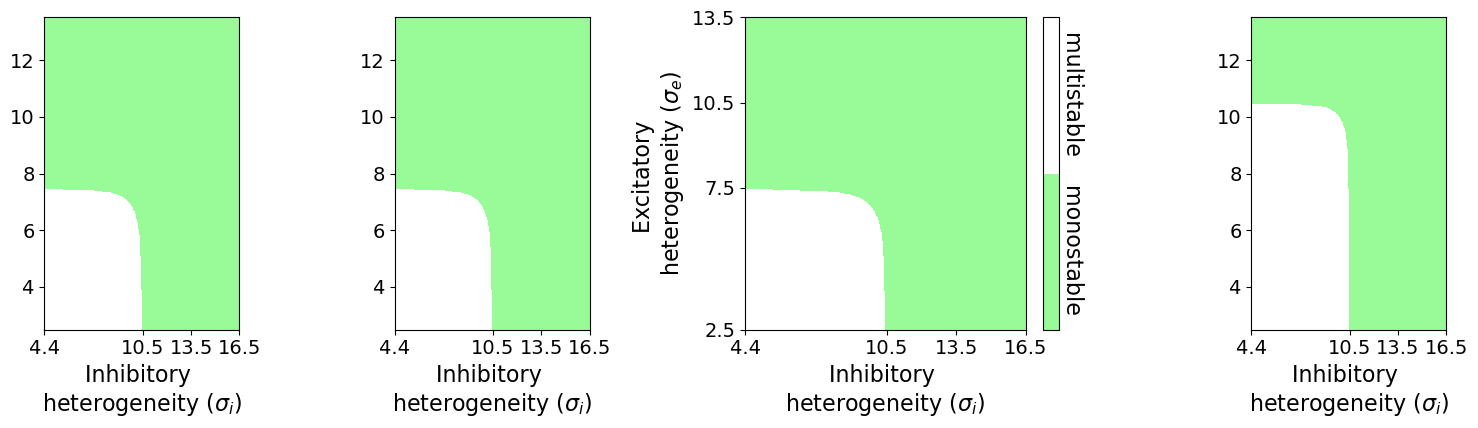

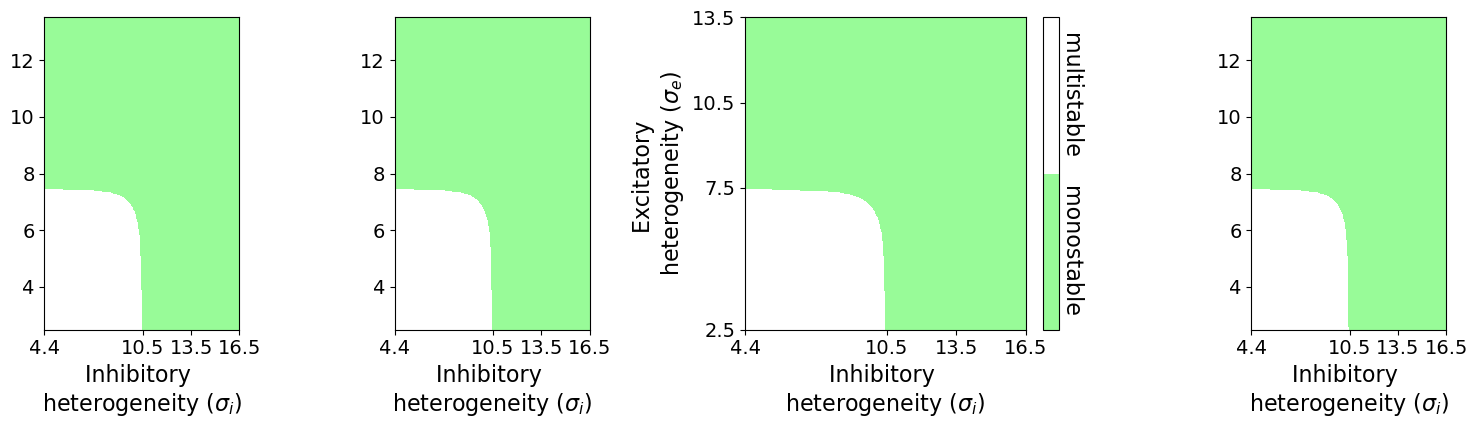

In [9]:
for Var in sigVar:
    fileLoad = f'MultiStable_DeltaIH_sigVar_{Var:.2f}.pkl'

    with open(os.path.join(figureroot, fileLoad), 'rb') as f:
        deltaI_arr = pickle.load(f)

    fileName = f'MultiStable_DeltaI_HeatMapH_sigVar_{Var:.2f}.jpg'

    encodeDeltaI = deepcopy(deltaI_arr)
    encodeDeltaI[encodeDeltaI <= 1.5] = 0
    encodeDeltaI[encodeDeltaI > 1.5] = 1


    fig, axs = plt.subplots(1, 4, figsize=(15, 4.5), gridspec_kw={'width_ratios':[1,1,1.8,1]})

    nRow = 0
    nCol = 0

    LETTER = 'ABCD'
    kInd = np.array([1, 4, 6, 7])
    for nK in kInd:
        response = deepcopy(encodeDeltaI[nK, :, :])
        mask = response == np.inf 
        response[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), response[~mask])

        y, x, r = cv_upsample(orig_response=response, eval_arrx=sigiArr, eval_arry=sigeArr, 
                                    y_max=max(sigeArr), y_min=min(sigeArr), x_max=max(sigiArr), x_min=min(sigiArr),
                                    sigma_x = 25, sigma_y = 25,  resolution = 500) 
        
        pcos = axs[nCol].pcolormesh(x, y, r, cmap=ListedColormap(['palegreen', 'white']))
        axs[nCol].set_xlabel(f"Inhibitory \nheterogeneity " + r"$(\sigma_i)$", fontsize=16)
        axs[nCol].set_xlim(4.4, max(x))
        axs[nCol].set_xticks(sigiArr)

        if nCol == 2:
            axs[nCol].set_ylabel("Excitatory \nheterogeneity " + r"$(\sigma_e)$", fontsize=16)
            axs[nCol].set_ylim(2.5, 13.5)
            axs[nCol].set_yticks(sigeArr)
        nCol += 1
        # axs[nRow, nCol].text(8, 10 , r"$K_{glob} = $" + f"{K_uniq[nK]:.2f}", fontsize=16)

    cbar = fig.colorbar(pcos, ax=axs[2], location='right', pad=0.05)
    cbar.ax.get_yaxis().set_ticks([])
    cbar.ax.text(1.75, -.5 , r"monostable", rotation=270, ha='center', va='center', fontsize=16)
    cbar.ax.text(1.75, .5 , r"multistable", rotation=270, ha='center', va='center', fontsize=16)

    plt.tight_layout()
    plt.savefig(os.path.join(figureroot, fileName), dpi=300)
    plt.show()

In [10]:
rootB = "Setup_B3v"
fp_dir = "results/fixedpoints"

save_str = datetime.datetime(2024, 4, 5)
sub_dir = f"exp-{save_str.year}-{save_str.month}-{save_str.day}"

loadB = os.path.join("../", rootB, fp_dir, sub_dir)

In [11]:
%%capture

for Var in sigVar:
    for sige in sigeArr:
        for sigi in sigiArr:
            filepaths = glob.glob(os.path.join(loadB, f"*_sige_{sige:.3f}_sigi_{sigi:.3f}_sigVar_{Var:.2f}.pkl"))
            print(f"E {sige:.3f} - I {sigi:.3f} - No. of files = {len(filepaths)}")
            sortpaths, Karr = sort_filesK(filepaths)

            for nf, filePath in enumerate(sortpaths):
                BaseName = os.path.basename(filePath).split('.pkl')[0]
                K = Karr[nf]
                
                with open(filePath, 'rb') as file_:
                    DataDict = pickle.load(file_)
                
                plot_dict = {'fig_size': (10, 8), 'xlabel': r"$I^1_e$", 'var_name': 'external stimulus'}
                file_str_k = f"Kglob_{K:.3f}_sige_{sige:.3f}_sigi_{sigi:.3f}L_sigVAr_{Var:.2f}.jpg"

                I = np.array(DataDict['FPVar']) / params['gamma']

                DF = dimreduction(DataDict, xVar='I', **params)

                textDelt = max(DF['U']/ params['gamma']) * 0.5
                plt.figure(figsize=(5, 2))
                plt.scatter(I, DF['U'] / params['gamma'], c=DF['FPType'], marker='.')
                plt.ylabel(r'$\psi(\mathbf{u})$', fontsize=16, labelpad=10)
                plt.xlabel(r"Modulatory signal input $(I^1_e)$", fontsize=16)
                plt.xlim(0, max(I))
                plt.savefig(os.path.join(figureroot, file_str_k), dpi=300, bbox_inches='tight')
                plt.show()

In [12]:
for Var in sigVar:
    fileName = f'MultiStable_DeltaIL_sigVar_{Var:.2f}.pkl'
    deltaI_arr = np.zeros((len(Karr), len(sigeArr), len(sigiArr)))   # region width in terms of K
    if os.path.isfile(os.path.join(figureroot, fileName)):
        print("File FOUND!")
        with open(os.path.join(figureroot, fileName), 'rb') as f:
            deltaI_arr = pickle.load(f)

    else:
        for nK in range (len(Karr)):
            K = Karr[nK]
            for nSE, sigE in enumerate(sigeArr):
                for nSI, sigI in enumerate(sigiArr):
                    _path = os.path.join(loadB, f"KGlob_{K:.2f}_sige_{sigE:.3f}_sigi_{sigI:.3f}_sigVar_{Var:.2f}.pkl")
                
                    with open(_path, 'rb') as file_:
                        DataDict = pickle.load(file_)

                    I = np.array(DataDict['FPVar']) / params['gamma']
                    IUniq = np.unique(I)
                    IDF = pd.DataFrame(I)
                    FPCount_dict = IDF.value_counts().sort_index().to_dict()

                    FP_count = np.array(list(FPCount_dict.values()))

                    MultiR_id = np.where(FP_count > 1)[0]
                    if len(MultiR_id) == 0:
                        continue

                    Mult_diffid = np.diff(MultiR_id)
                    markers = np.where(Mult_diffid > 5)[0] + 1
                    nRegions = len(markers)

                    if nRegions:
                        segment_delt = []
                        start_marker = 0

                        for i in range(nRegions + 1):
                            if i !=  nRegions:
                                marker = markers[i]
                                segment = MultiR_id[start_marker:marker]
                            else:
                                segment = MultiR_id[start_marker:]
                            
                            if i < nRegions:
                                start_marker = marker

                            segment_delt.append(IUniq[segment[-1]] - IUniq[segment[0]]) if len(segment) > 0 else 0
                        
                        deltaI_arr[nK, nSE, nSI] = sum(segment_delt)

                    else:
                        deltaI_arr[nK, nSE, nSI] = IUniq[MultiR_id[-1]] - IUniq[MultiR_id[0]]       
        
        with open(os.path.join(figureroot, fileName), 'wb') as f:
            pickle.dump(deltaI_arr, f)  

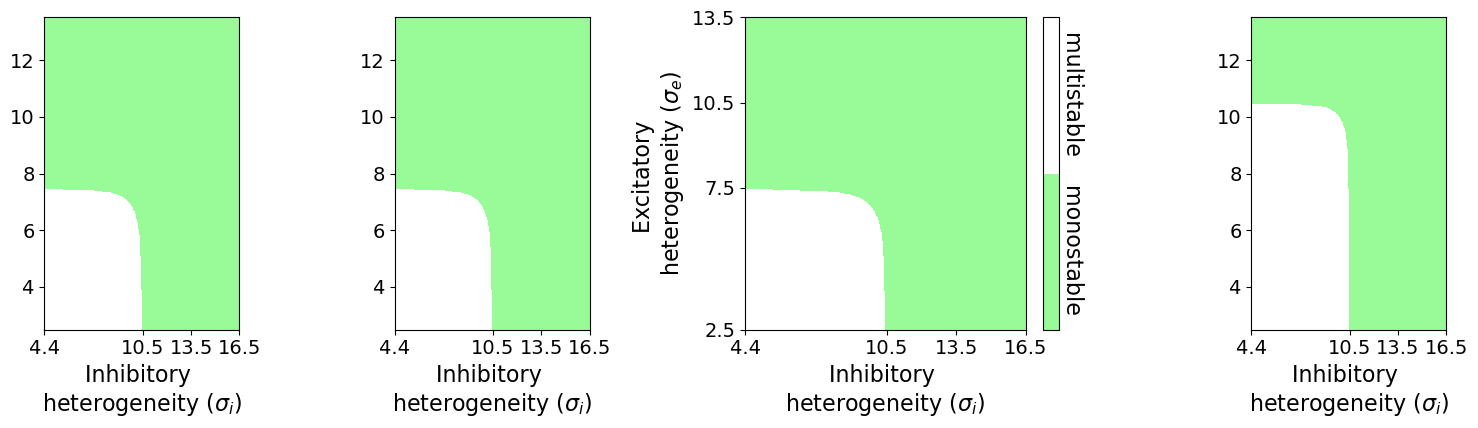

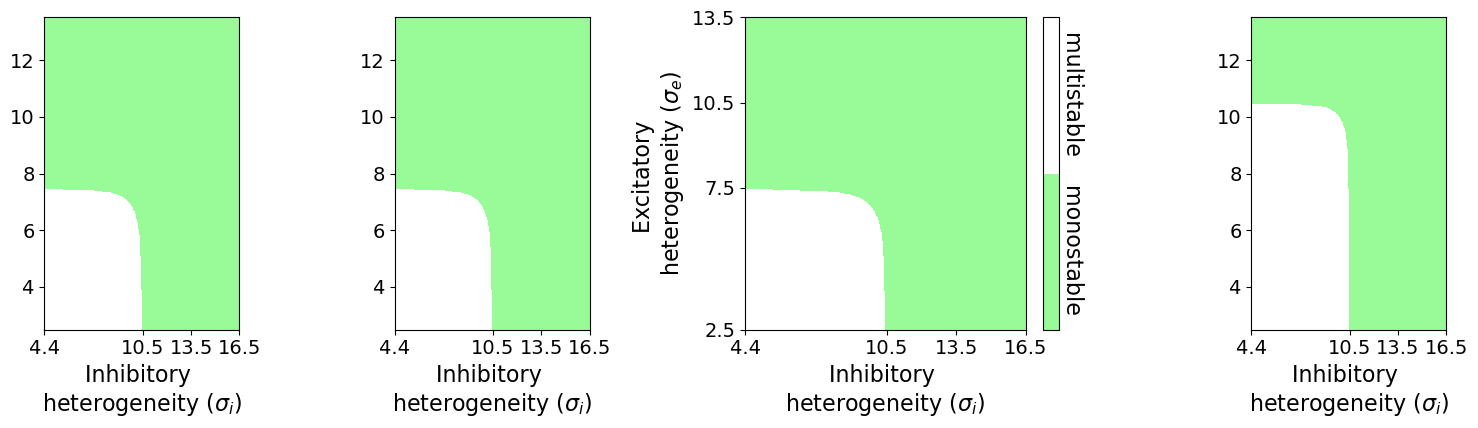

In [13]:
for Var in sigVar:
    fileLoad = f'MultiStable_DeltaIL_sigVar_{Var:.2f}.pkl'

    with open(os.path.join(figureroot, fileLoad), 'rb') as f:
        deltaI_arr = pickle.load(f)

    fileName = f'MultiStable_DeltaI_HeatMapL_sigVar_{Var:.2f}.jpg'

    encodeDeltaI = deepcopy(deltaI_arr)
    encodeDeltaI[encodeDeltaI <= 1.5] = 0
    encodeDeltaI[encodeDeltaI > 1.5] = 1


    fig, axs = plt.subplots(1, 4, figsize=(15, 4.5), gridspec_kw={'width_ratios':[1,1,1.8,1]})

    nRow = 0
    nCol = 0

    LETTER = 'ABCD'
    kInd = np.array([1, 4, 6, 7])
    for nK in kInd:
        response = deepcopy(encodeDeltaI[nK, :, :])
        mask = response == np.inf 
        response[mask] = np.interp(np.flatnonzero(mask), np.flatnonzero(~mask), response[~mask])

        y, x, r = cv_upsample(orig_response=response, eval_arrx=sigiArr, eval_arry=sigeArr, 
                                    y_max=max(sigeArr), y_min=min(sigeArr), x_max=max(sigiArr), x_min=min(sigiArr),
                                    sigma_x = 25, sigma_y = 25,  resolution = 500) 
        
        pcos = axs[nCol].pcolormesh(x, y, r, cmap=ListedColormap(['palegreen', 'white']))
        axs[nCol].set_xlabel(f"Inhibitory \nheterogeneity " + r"$(\sigma_i)$", fontsize=16)
        axs[nCol].set_xlim(4.4, max(x))
        axs[nCol].set_xticks(sigiArr)

        if nCol == 2:
            axs[nCol].set_ylabel("Excitatory \nheterogeneity " + r"$(\sigma_e)$", fontsize=16)
            axs[nCol].set_ylim(2.5, 13.5)
            axs[nCol].set_yticks(sigeArr)
        nCol += 1
        # axs[nRow, nCol].text(8, 10 , r"$K_{glob} = $" + f"{K_uniq[nK]:.2f}", fontsize=16)

    cbar = fig.colorbar(pcos, ax=axs[2], location='right', pad=0.05)
    cbar.ax.get_yaxis().set_ticks([])
    cbar.ax.text(1.75, -.5 , r"monostable", rotation=270, ha='center', va='center', fontsize=16)
    cbar.ax.text(1.75, .5 , r"multistable", rotation=270, ha='center', va='center', fontsize=16)

    plt.tight_layout()
    plt.savefig(os.path.join(figureroot, fileName), dpi=300)
    plt.show()